<a href="https://colab.research.google.com/github/MachadoECM/Precificacao_de_seguros/blob/main/Precificacao_Seguros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1 - Leitura da BD e carregar as bibliotecas iniciais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
data_seg = pd.read_csv('/content/drive/MyDrive/Precificacao_Seguros/Precificacao_Seguros.csv')
data_seg.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


###2 - Veirificar a quantidade de valores faltantes e as categorias das variáveis.

In [4]:
data_seg.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
data_seg.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


### 3 - Descrição das Variáveis Numéricas

Vamos começar obtendo as estatísticas descritivas para as colunas numéricas do DataFrame `data_seg`.

In [7]:
display(data_seg.describe())

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 4 - Descrição das Variáveis Categóricas

Agora, vamos verificar a distribuição de valores para cada uma das colunas categóricas (do tipo 'object').

In [8]:
for col in data_seg.select_dtypes(include='object').columns:
    print(f"\nValue counts for column '{col}':")
    display(data_seg[col].value_counts())


Value counts for column 'sex':


,count
sex,
male,676
female,662



Value counts for column 'smoker':


,count
smoker,
no,1064
yes,274



Value counts for column 'region':


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


### 5 - Visualização das Variáveis Quantitativas: Boxplots

Vamos criar boxplots para cada uma das variáveis numéricas para entender melhor suas distribuições, mediana, quartis e identificar possíveis outliers.

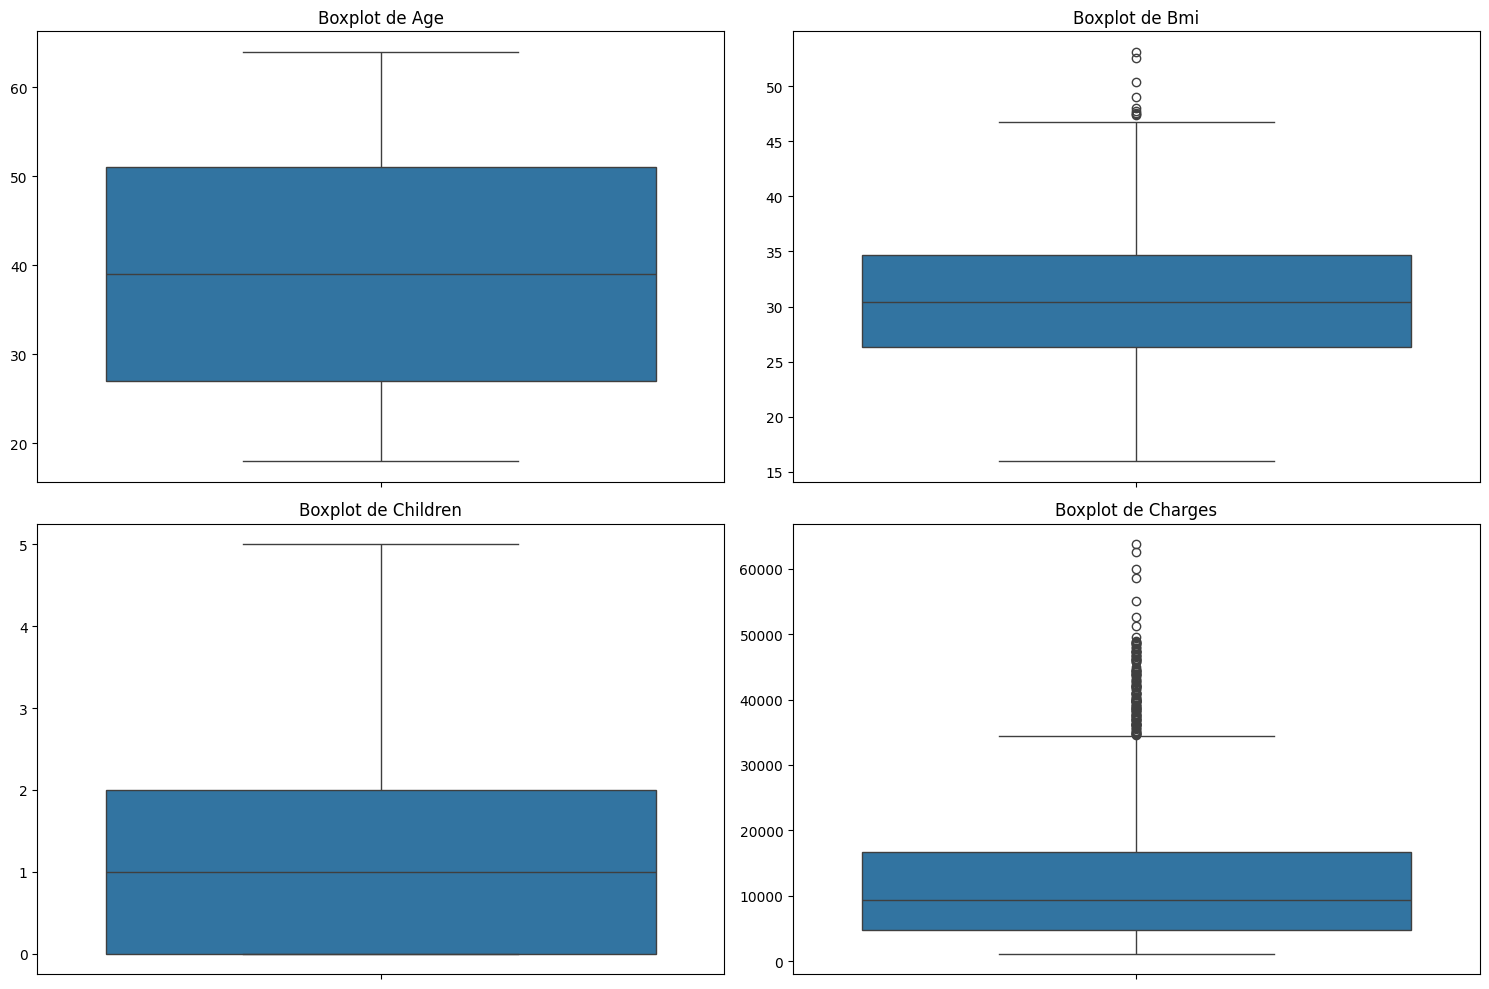

In [9]:
numerical_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=data_seg[col])
    plt.title(f'Boxplot de {col.capitalize()}')
    plt.ylabel('') # Remove y-label to avoid redundancy
plt.tight_layout()
plt.show()

### 6 - Investigação de Outliers na Variável 'Charges' com Scatter Plots

Agora, vamos usar scatter plots para explorar a relação entre a variável 'charges' e as outras variáveis no dataset, buscando identificar padrões ou fatores que contribuem para os valores extremos observados nos boxplots.

#### 6.1 - 'Charges' vs. Variáveis Numéricas

Vamos começar visualizando 'charges' em relação a 'age', 'bmi' e 'children'.

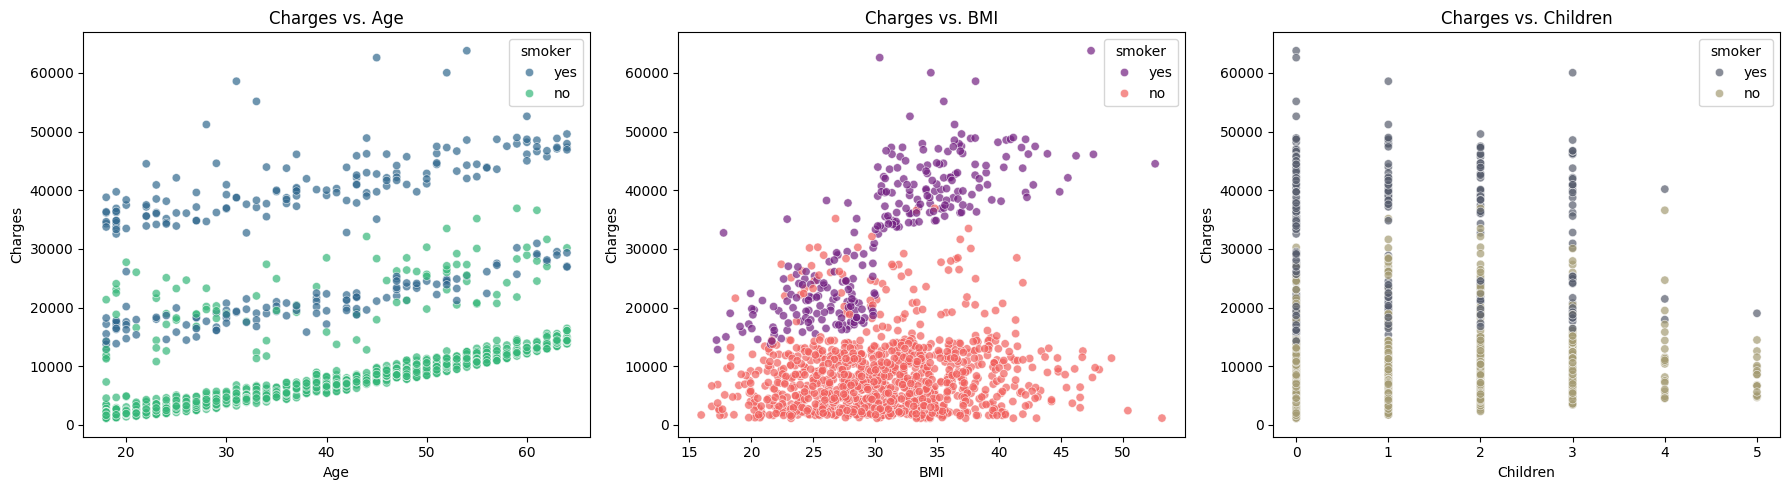

In [10]:
plt.figure(figsize=(18, 5))

# Scatter plot: Charges vs. Age
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='charges', data=data_seg, hue='smoker', palette='viridis', alpha=0.7)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')

# Scatter plot: Charges vs. BMI
plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='charges', data=data_seg, hue='smoker', palette='magma', alpha=0.7)
plt.title('Charges vs. BMI')
plt.xlabel('BMI')
plt.ylabel('Charges')

# Scatter plot: Charges vs. Children
plt.subplot(1, 3, 3)
sns.scatterplot(x='children', y='charges', data=data_seg, hue='smoker', palette='cividis', alpha=0.7)
plt.title('Charges vs. Children')
plt.xlabel('Children')
plt.ylabel('Charges')

plt.tight_layout()
plt.show()

#### 6.2 - 'Charges' vs. Variáveis Categóricas

Em seguida, vamos analisar 'charges' em relação a 'sex', 'smoker' e 'region' usando boxplots ou violin plots, que são mais adequados para uma variável quantitativa contra uma categórica.

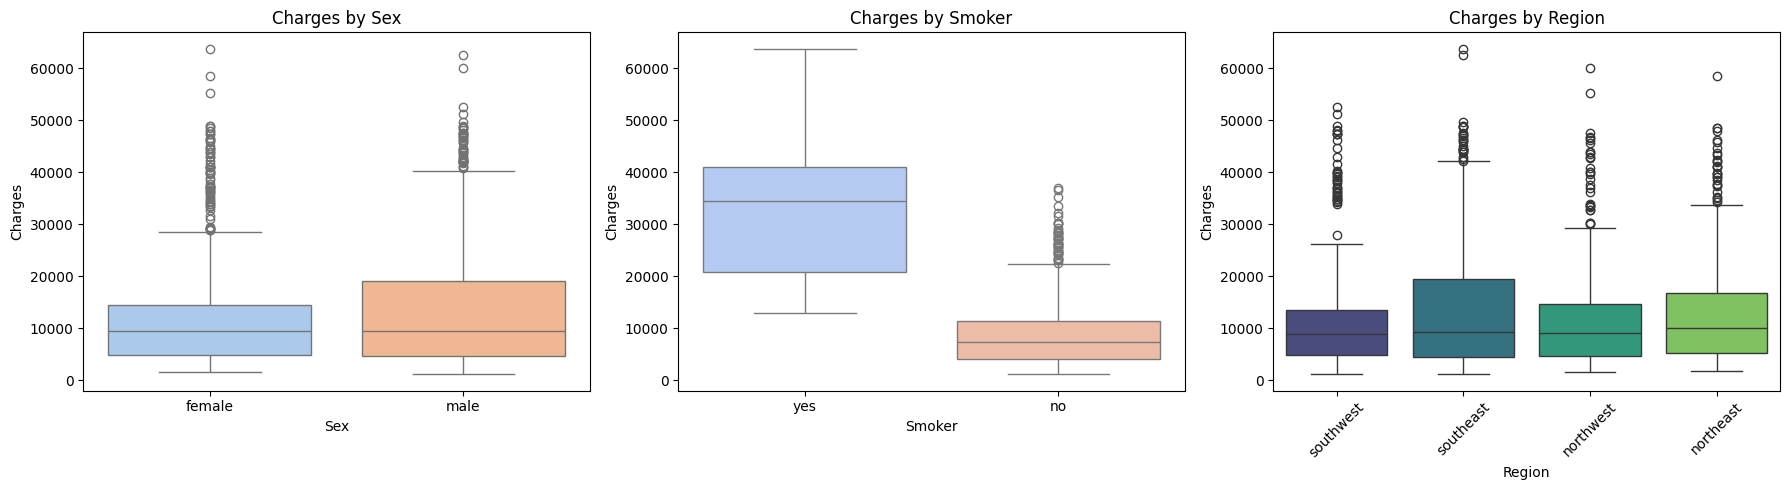

In [12]:
plt.figure(figsize=(18, 5))

# Boxplot: Charges vs. Sex
plt.subplot(1, 3, 1)
sns.boxplot(x='sex', y='charges', data=data_seg, hue='sex', palette='pastel', legend=False)
plt.title('Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Charges')

# Boxplot: Charges vs. Smoker
plt.subplot(1, 3, 2)
sns.boxplot(x='smoker', y='charges', data=data_seg, hue='smoker', palette='coolwarm', legend=False)
plt.title('Charges by Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')

# Boxplot: Charges vs. Region
plt.subplot(1, 3, 3)
sns.boxplot(x='region', y='charges', data=data_seg, hue='region', palette='viridis', legend=False)
plt.title('Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 7 - Correlação entre 'Smoker' e 'Charges'

Vamos calcular a correlação de Pearson entre a variável 'smoker' (após codificação numérica) e 'charges' para quantificar a força e a direção de sua relação.

In [13]:
# Codificar a variável 'smoker' para numérica
data_seg['smoker_encoded'] = data_seg['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# Calcular a correlação entre 'smoker_encoded' e 'charges'
correlation = data_seg['smoker_encoded'].corr(data_seg['charges'])

print(f"A correlação entre 'smoker' e 'charges' é: {correlation:.4f}")

A correlação entre 'smoker' e 'charges' é: 0.7873


### 8 - Matriz de Correlação Completa

Vamos calcular a matriz de correlação de Pearson entre todas as variáveis numéricas do dataset para entender as relações lineares entre elas.

In [14]:
numerical_cols_for_corr = ['age', 'bmi', 'children', 'charges', 'smoker_encoded']
correlation_matrix = data_seg[numerical_cols_for_corr].corr()
display(correlation_matrix)

,age,bmi,children,charges,smoker_encoded
age,1.000000,0.109272,0.042469,0.299008,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.787251
smoker_encoded,-0.025019,0.003750,0.007673,0.787251,1.000000


#### Visualização da Matriz de Correlação com Heatmap

Para uma visualização mais intuitiva, vamos usar um heatmap.

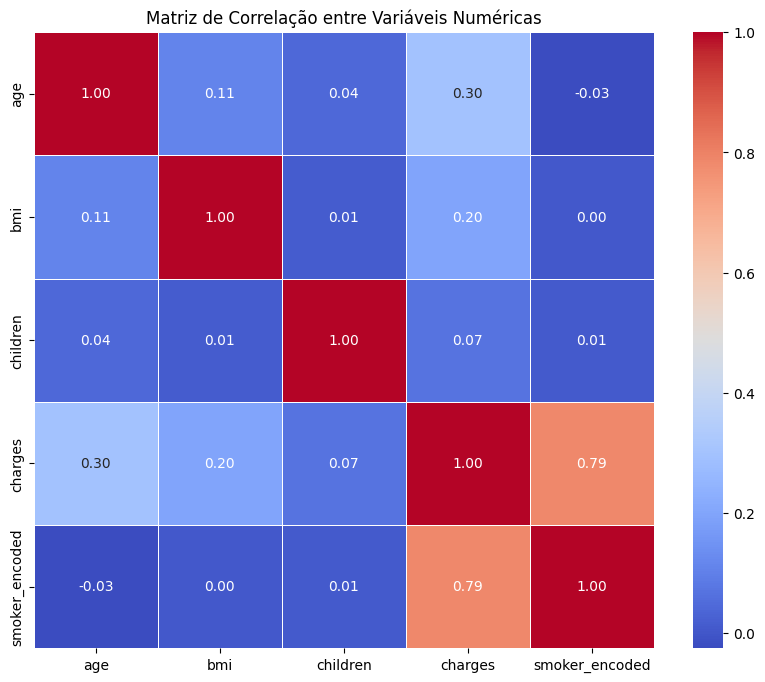

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

### 9 - Teste de Hipótese: Comparação de Médias de 'Charges' entre Fumantes e Não Fumantes

Com base nas análises exploratórias que indicaram uma forte diferença nas 'charges' entre fumantes e não fumantes, vamos formalizar isso com um teste de hipótese. Usaremos um teste t de duas amostras independentes para verificar se a diferença nas médias é estatisticamente significativa.

In [16]:
from scipy import stats

# Separar os dados de 'charges' para fumantes e não fumantes
smoker_charges = data_seg[data_seg['smoker'] == 'yes']['charges']
non_smoker_charges = data_seg[data_seg['smoker'] == 'no']['charges']

# Realizar o teste t de duas amostras independentes
# Assumindo variâncias desiguais (Welch's t-test) devido à grande diferença de variância observada em boxplots anteriores
t_statistic, p_value = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

print(f"Estatística t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.4e}") # Usando notação científica para p-value muito pequeno

# Interpretar o resultado
alpha = 0.05
if p_value < alpha:
    print(f"Com p-value ({p_value:.4e}) menor que o nível de significância ({alpha}), rejeitamos a hipótese nula.")
    print("Há uma diferença estatisticamente significativa nas médias de 'charges' entre fumantes e não fumantes.")
else:
    print(f"Com p-value ({p_value:.4e}) maior que o nível de significância ({alpha}), não rejeitamos a hipótese nula.")
    print("Não há evidência estatística para uma diferença nas médias de 'charges' entre fumantes e não fumantes.")

Estatística t: 32.7519
Valor p: 5.8895e-103
Com p-value (5.8895e-103) menor que o nível de significância (0.05), rejeitamos a hipótese nula.
Há uma diferença estatisticamente significativa nas médias de 'charges' entre fumantes e não fumantes.


### 10 - Regressão Linear

A Regressão Linear é uma técnica estatística e um dos algoritmos de Machine Learning mais simples e fundamentais, utilizada para modelar a relação entre uma variável dependente (que queremos prever) e uma ou mais variáveis independentes (as características ou *features*). O objetivo é encontrar a linha que melhor se ajusta aos dados, minimizando a soma dos quadrados das diferenças entre os valores observados e os valores previstos.

No nosso caso, a variável dependente será 'charges' e as variáveis independentes serão 'age', 'bmi' e 'smoker_encoded'.

#### 10.1 - Preparação dos Dados para Regressão Linear

Primeiro, vamos definir as variáveis preditoras (X) e a variável alvo (y). Em seguida, dividiremos os dados em conjuntos de treino e teste.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Definir as variáveis preditoras (X) e a variável alvo (y)
X = data_seg[['age', 'bmi', 'smoker_encoded']]
y = data_seg['charges']

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

Tamanho do conjunto de treino: 1070 amostras
Tamanho do conjunto de teste: 268 amostras


#### 10.2 - Treinamento do Modelo de Regressão Linear

Agora, vamos criar e treinar o modelo de Regressão Linear.

In [18]:
# Criar o modelo de regressão linear
model = LinearRegression()

# Treinar o modelo
model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso!")
print(f"Coeficiente (inclinação) para 'age': {model.coef_[0]:.4f}")
print(f"Coeficiente (inclinação) para 'bmi': {model.coef_[1]:.4f}")
print(f"Coeficiente (inclinação) para 'smoker_encoded': {model.coef_[2]:.4f}")
print(f"Intercepto: {model.intercept_:.4f}")

Modelo de Regressão Linear treinado com sucesso!
Coeficiente (inclinação) para 'age': 259.4102
Coeficiente (inclinação) para 'bmi': 326.4502
Coeficiente (inclinação) para 'smoker_encoded': 23675.3718
Intercepto: -11707.8023


#### 10.3 - Avaliação do Modelo

Finalmente, vamos avaliar o desempenho do modelo usando o conjunto de testes.

In [19]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"R-quadrado (R²): {r2:.4f}")

Erro Quadrático Médio (MSE): 34512843.88
R-quadrado (R²): 0.7777


### 11 - Adicionando 'Sex' e 'Children' ao Modelo de Regressão Linear

Agora, vamos expandir nosso modelo de regressão linear para incluir as variáveis 'sex' e 'children'. Como 'sex' é uma variável categórica, precisaremos convertê-la em um formato numérico adequado para o modelo.

#### 11.1 - Codificação da Variável 'Sex'

Vamos codificar 'sex' em uma variável binária (ex: 0 para 'female', 1 para 'male').

In [20]:
# Codificar a variável 'sex' para numérica
data_seg['sex_encoded'] = data_seg['sex'].apply(lambda x: 1 if x == 'male' else 0)

print("Coluna 'sex_encoded' criada com sucesso!")
print(data_seg[['sex', 'sex_encoded']].head())

Coluna 'sex_encoded' criada com sucesso!
      sex  sex_encoded
0  female            0
1    male            1
2    male            1
3    male            1
4    male            1


#### 11.2 - Treinamento e Avaliação do Novo Modelo

Com a variável 'sex' codificada e 'children' já numérica, vamos redefinir nossas variáveis preditoras, dividir os dados novamente, e treinar e avaliar o modelo com o conjunto expandido de features.

In [21]:
# Definir as novas variáveis preditoras (X) e a variável alvo (y)
X_new = data_seg[['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded']]
y_new = data_seg['charges']

# Dividir os dados em conjuntos de treino e teste
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Criar e treinar o novo modelo de regressão linear
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

print("Novo Modelo de Regressão Linear treinado com sucesso!")
print(f"Coeficiente (inclinação) para 'age': {model_new.coef_[0]:.4f}")
print(f"Coeficiente (inclinação) para 'bmi': {model_new.coef_[1]:.4f}")
print(f"Coeficiente (inclinação) para 'children': {model_new.coef_[2]:.4f}")
print(f"Coeficiente (inclinação) para 'smoker_encoded': {model_new.coef_[3]:.4f}")
print(f"Coeficiente (inclinação) para 'sex_encoded': {model_new.coef_[4]:.4f}")
print(f"Intercepto: {model_new.intercept_:.4f}")

# Fazer previsões no novo conjunto de teste
y_pred_new = model_new.predict(X_test_new)

# Avaliar o desempenho do novo modelo
mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"\nNovo Erro Quadrático Médio (MSE): {mse_new:.2f}")
print(f"Novo R-quadrado (R²): {r2_new:.4f}")

Novo Modelo de Regressão Linear treinado com sucesso!
Coeficiente (inclinação) para 'age': 257.0690
Coeficiente (inclinação) para 'bmi': 327.5335
Coeficiente (inclinação) para 'children': 427.2544
Coeficiente (inclinação) para 'smoker_encoded': 23653.9033
Coeficiente (inclinação) para 'sex_encoded': -7.9518
Intercepto: -12113.4513

Novo Erro Quadrático Médio (MSE): 33979257.05
Novo R-quadrado (R²): 0.7811


### 12 - Modificando o Modelo: Removendo 'Sex' e Adicionando 'Region'

Agora, vamos ajustar o modelo novamente: removeremos a variável 'sex' (que mostrou impacto desprezível) e incluiremos a variável categórica 'region'. Como 'region' possui múltiplas categorias, precisaremos usar One-Hot Encoding.

#### 12.1 - One-Hot Encoding da Variável 'Region'

Vamos usar `pd.get_dummies` para converter a variável 'region' em múltiplas colunas binárias.

In [22]:
# Aplicar One-Hot Encoding à variável 'region'
data_seg_encoded = pd.get_dummies(data_seg, columns=['region'], drop_first=True, dtype=int)

print("Variável 'region' codificada com sucesso!")
display(data_seg_encoded[['region_northwest', 'region_southeast', 'region_southwest']].head())

Variável 'region' codificada com sucesso!


,region_northwest,region_southeast,region_southwest
0,0,0,1
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0


#### 12.2 - Treinamento e Avaliação do Novo Modelo (com 'Region', sem 'Sex')

Agora, vamos definir as novas variáveis preditoras (incluindo as colunas de 'region' codificadas e 'children', mas excluindo 'sex_encoded'), treinar e avaliar o modelo.

In [23]:
# Definir as novas variáveis preditoras (X) e a variável alvo (y)
X_final = data_seg_encoded[['age', 'bmi', 'children', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']]
y_final = data_seg_encoded['charges']

# Dividir os dados em conjuntos de treino e teste
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Criar e treinar o novo modelo de regressão linear
model_final = LinearRegression()
model_final.fit(X_train_final, y_train_final)

print("Modelo de Regressão Linear final treinado com sucesso!")
print(f"Coeficiente (inclinação) para 'age': {model_final.coef_[0]:.4f}")
print(f"Coeficiente (inclinação) para 'bmi': {model_final.coef_[1]:.4f}")
print(f"Coeficiente (inclinação) para 'children': {model_final.coef_[2]:.4f}")
print(f"Coeficiente (inclinação) para 'smoker_encoded': {model_final.coef_[3]:.4f}")
print(f"Coeficiente (inclinação) para 'region_northwest': {model_final.coef_[4]:.4f}")
print(f"Coeficiente (inclinação) para 'region_southeast': {model_final.coef_[5]:.4f}")
print(f"Coeficiente (inclinação) para 'region_southwest': {model_final.coef_[6]:.4f}")
print(f"Intercepto: {model_final.intercept_:.4f}")

# Fazer previsões no conjunto de teste
y_pred_final = model_final.predict(X_test_final)

# Avaliar o desempenho do novo modelo
mse_final = mean_squared_error(y_test_final, y_pred_final)
r2_final = r2_score(y_test_final, y_pred_final)

print(f"\nErro Quadrático Médio (MSE) Final: {mse_final:.2f}")
print(f"R-quadrado (R²) Final: {r2_final:.4f}")

Modelo de Regressão Linear final treinado com sucesso!
Coeficiente (inclinação) para 'age': 256.9813
Coeficiente (inclinação) para 'bmi': 337.0578
Coeficiente (inclinação) para 'children': 425.1575
Coeficiente (inclinação) para 'smoker_encoded': 23649.4937
Coeficiente (inclinação) para 'region_northwest': -370.9029
Coeficiente (inclinação) para 'region_southeast': -657.4698
Coeficiente (inclinação) para 'region_southwest': -809.4842
Intercepto: -11939.5579

Erro Quadrático Médio (MSE) Final: 33602504.51
R-quadrado (R²) Final: 0.7836


### 13 - Comparação com um Modelo de Regressão por Árvore de Decisão

Agora, vamos treinar um modelo de Regressão por Árvore de Decisão (`DecisionTreeRegressor`) usando as mesmas variáveis e o mesmo conjunto de dados para comparar seu desempenho com o da Regressão Linear.

In [24]:
from sklearn.tree import DecisionTreeRegressor

# Definir as variáveis preditoras (X) e a variável alvo (y) - usando as mesmas do modelo LinearRegression final
X_dt = data_seg_encoded[['age', 'bmi', 'children', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']]
y_dt = data_seg_encoded['charges']

# Dividir os dados em conjuntos de treino e teste (usando o mesmo random_state para comparação justa)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Criar e treinar o modelo de Árvore de Decisão
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

print("Modelo de Regressão por Árvore de Decisão treinado com sucesso!")

# Fazer previsões no conjunto de teste
y_pred_dt = dt_model.predict(X_test_dt)

# Avaliar o desempenho do modelo de Árvore de Decisão
mse_dt = mean_squared_error(y_test_dt, y_pred_dt)
r2_dt = r2_score(y_test_dt, y_pred_dt)

print(f"\nErro Quadrático Médio (MSE) - Decision Tree: {mse_dt:.2f}")
print(f"R-quadrado (R²) - Decision Tree: {r2_dt:.4f}")

# Comparar com o modelo de Regressão Linear Final
print("\n--- Comparação com Regressão Linear Final ---")
print(f"MSE Regressão Linear: {mse_final:.2f}")
print(f"R² Regressão Linear: {r2_final:.4f}")

Modelo de Regressão por Árvore de Decisão treinado com sucesso!

Erro Quadrático Médio (MSE) - Decision Tree: 39876049.53
R-quadrado (R²) - Decision Tree: 0.7431

--- Comparação com Regressão Linear Final ---
MSE Regressão Linear: 33602504.51
R² Regressão Linear: 0.7836


### 14 - Testando o Random Forest Regressor

Agora, vamos testar um modelo de Regressor de Floresta Aleatória (`RandomForestRegressor`) para ver se conseguimos melhorar o desempenho em relação aos modelos de Regressão Linear e Árvore de Decisão.

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Usar as mesmas variáveis preditoras (X_final) e a variável alvo (y_final) do modelo LinearRegression
# Os conjuntos de treino e teste já foram definidos como X_train_final, X_test_final, y_train_final, y_test_final

# Criar e treinar o modelo de Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_final, y_train_final)

print("Modelo Random Forest Regressor treinado com sucesso!")

# Fazer previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test_final)

# Avaliar o desempenho do modelo Random Forest Regressor
mse_rf = mean_squared_error(y_test_final, y_pred_rf)
r2_rf = r2_score(y_test_final, y_pred_rf)

print(f"\nErro Quadrático Médio (MSE) - Random Forest: {mse_rf:.2f}")
print(f"R-quadrado (R²) - Random Forest: {r2_rf:.4f}")

# Comparar com os modelos anteriores
print("\n--- Comparação com Modelos Anteriores ---")
print(f"MSE Regressão Linear (Final): {mse_final:.2f}")
print(f"R² Regressão Linear (Final): {r2_final:.4f}")
print(f"MSE Decision Tree: {mse_dt:.2f}")
print(f"R² Decision Tree: {r2_dt:.4f}")

Modelo Random Forest Regressor treinado com sucesso!

Erro Quadrático Médio (MSE) - Random Forest: 20255300.47
R-quadrado (R²) - Random Forest: 0.8695

--- Comparação com Modelos Anteriores ---
MSE Regressão Linear (Final): 33602504.51
R² Regressão Linear (Final): 0.7836
MSE Decision Tree: 39876049.53
R² Decision Tree: 0.7431


### 15 - Importância das Variáveis no Random Forest Regressor

Vamos analisar a importância de cada variável (feature) para o modelo de Random Forest. Este atributo nos ajuda a entender quais características foram mais relevantes para as previsões do modelo.

Importância das Features no Random Forest Regressor:


,Feature,Importance
3,smoker_encoded,0.608619
1,bmi,0.221572
0,age,0.134376
2,children,0.020261
5,region_southeast,0.005665
4,region_northwest,0.005527
6,region_southwest,0.003980


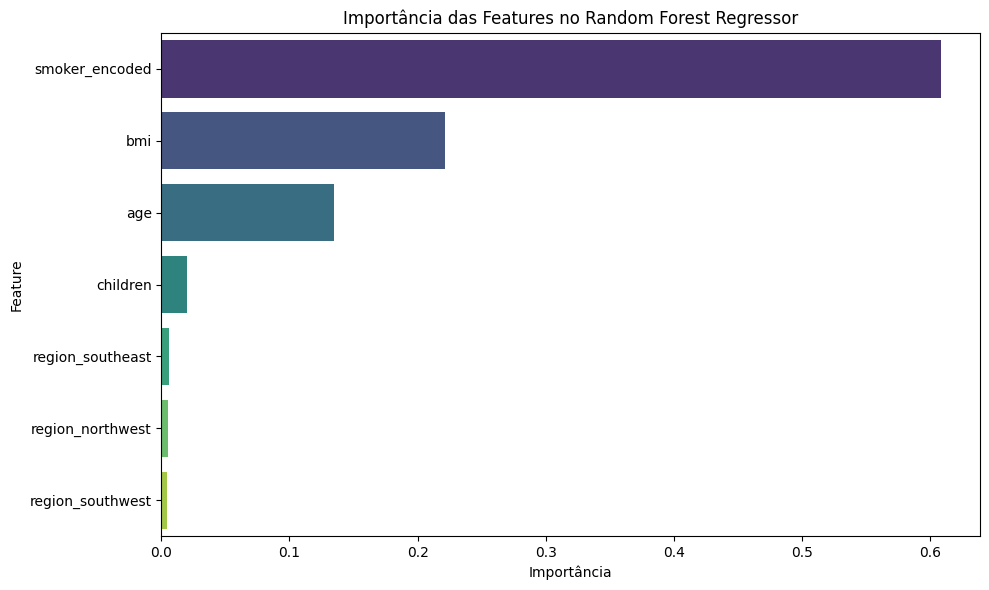

In [27]:
# Obter a importância das features
feature_importances = rf_model.feature_importances_

# Criar um DataFrame para melhor visualização
features_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': feature_importances
})

# Ordenar as features pela importância
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Importância das Features no Random Forest Regressor:")
display(features_df)

# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Features no Random Forest Regressor')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

O gráfico e a tabela acima mostram a importância relativa de cada variável para o modelo de Random Forest. Quanto maior a barra (ou o valor de 'Importance'), mais a variável contribuiu para a previsão das 'charges'. Como esperado de nossas análises anteriores, a variável 'smoker_encoded' deve ser a mais influente.

### 16 - Visualização das Previsões do Random Forest Regressor

Para ter uma ideia visual do desempenho do nosso `RandomForestRegressor`, vamos criar um gráfico de dispersão comparando os valores reais (`y_test_final`) com os valores previstos pelo modelo (`y_pred_rf`). Uma linha diagonal será adicionada para representar a previsão perfeita, onde os valores previstos seriam iguais aos valores reais.

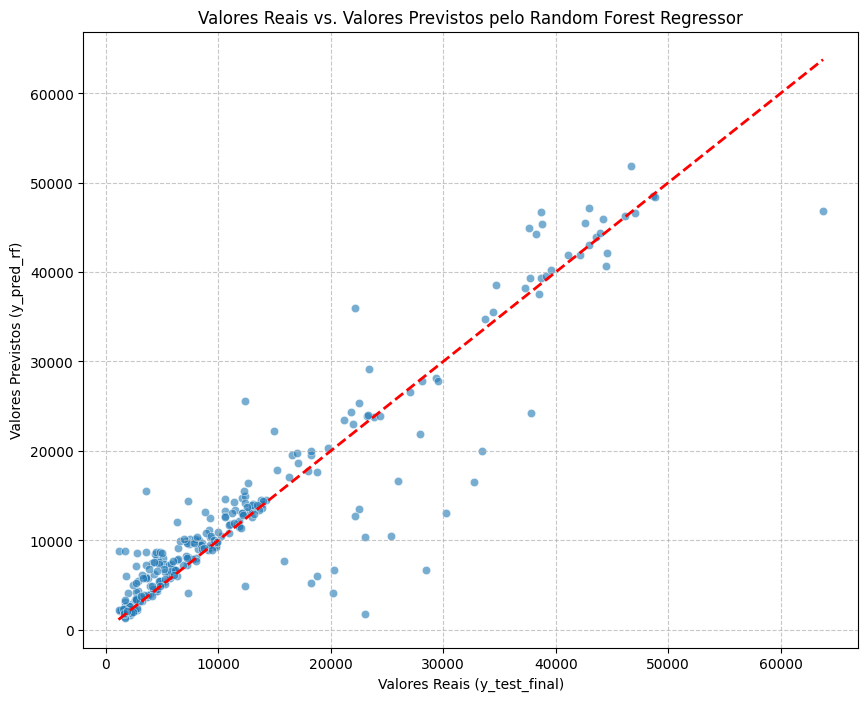

In [28]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_final, y=y_pred_rf, alpha=0.6)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'r--', lw=2) # Linha de previsão perfeita
plt.xlabel('Valores Reais (y_test_final)')
plt.ylabel('Valores Previstos (y_pred_rf)')
plt.title('Valores Reais vs. Valores Previstos pelo Random Forest Regressor')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 17 - Métricas Adicionais de Avaliação do Modelo Random Forest

Além do MSE e do R-quadrado, outras métricas como o Erro Médio Absoluto (MAE) e a Raiz do Erro Quadrático Médio (RMSE) podem fornecer insights valiosos sobre o desempenho do modelo.

In [31]:
from sklearn.metrics import mean_absolute_error

# Calcular MAE
mae_rf = mean_absolute_error(y_test_final, y_pred_rf)

# Calcular RMSE
rmse_rf = np.sqrt(mse_rf)

# Reexibir as métricas anteriores para comparação
print("\n--- Comparação Completa de Métricas ---")
print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.4f}, MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")


--- Comparação Completa de Métricas ---
Random Forest - MSE: 20255300.47, R²: 0.8695, MAE: 2473.87, RMSE: 4500.59


### 18 - Salvando o Modelo Random Forest

Para que possamos utilizar o modelo treinado no futuro sem a necessidade de retreiná-lo, vamos salvá-lo em um arquivo. Usaremos a biblioteca `joblib`, que é eficiente para serializar modelos do scikit-learn.

In [32]:
import joblib

# Definir o nome do arquivo para salvar o modelo
model_filename = 'random_forest_regressor_model.joblib'

# Salvar o modelo em disco
joblib.dump(rf_model, model_filename)

print(f"Modelo Random Forest Regressor salvo como '{model_filename}'")

# Exemplo de como carregar o modelo (opcional, para demonstração)
# loaded_model = joblib.load(model_filename)
# print(f"Modelo carregado: {loaded_model}")

Modelo Random Forest Regressor salvo como 'random_forest_regressor_model.joblib'


### 19 - Exemplo de previsão do valor do seguro para novos dados

Agora que o modelo está salvo, podemos carregá-lo a qualquer momento para fazer previsões em novos dados sem precisar retreiná-lo. Vamos demonstrar como carregar o modelo e fazer uma previsão para um novo 'cliente'.

In [34]:
import joblib
import pandas as pd

# Carregar o modelo salvo
model_filename = 'random_forest_regressor_model.joblib'
loaded_rf_model = joblib.load(model_filename)

print(f"Modelo '{model_filename}' carregado com sucesso!")

# Criar novos dados para previsão (exemplo)
# As colunas devem corresponder às usadas no treinamento do modelo:
# 'age', 'bmi', 'children', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest'

# Exemplo de um novo indivíduo:
# Idade: 30, BMI: 25, Filhos: 1, Fumante: Não, Região: Sudeste
new_data = pd.DataFrame({
    'age': [30],
    'bmi': [25.0],
    'children': [1],
    'smoker_encoded': [0], # 0 para não fumante
    'region_northwest': [0],
    'region_southeast': [1], # 1 para sudeste
    'region_southwest': [0]
})

print("\nNovos dados para previsão:")
display(new_data)

# Realizar a previsão
predicted_charge = loaded_rf_model.predict(new_data)

print(f"\nCusto de seguro previsto para o novo indivíduo: ${predicted_charge[0]:.2f}")


Modelo 'random_forest_regressor_model.joblib' carregado com sucesso!

Novos dados para previsão:


,age,bmi,children,smoker_encoded,region_northwest,region_southeast,region_southwest
0,30,25.0,1,0,0,1,0



Custo de seguro previsto para o novo indivíduo: $9570.60
